
# Transformer Model for Strudel code generation

# Import statements

In [1]:
#import statements
import os
import re
import json
import pickle
import numpy as np
from collections import Counter
from pathlib import Path
import numpy as np
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

# PreProcessing

In [ ]:
# Tokenizer / Preprocessor for Strudel music files
class StrudelPreprocessor:
    def __init__(self, data_dir='StrudelOutput'):
        self.data_dir = data_dir
        self.vocabulary = {}        # Maps tokens to indices
        self.reverse_vocab = {}     # Maps indices back to tokens
        self.token_counts = Counter()  # Counts occurrences of each token
        
    # Parse a single Strudel file
    def parse_strudel_file(self, filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
        
        # Extract CPM (characters per minute) if present
        cpm_match = re.search(r'setcpm\(([\d./]+)\)', content)
        cpm = cpm_match.group(1) if cpm_match else None
        
        # Extract all note blocks
        note_blocks = []
        note_pattern = r'\$:\s*note\(`<([^>]+)>`\)'
        for match in re.finditer(note_pattern, content, re.DOTALL):
            note_content = match.group(1).strip()
            lines = [line.strip() for line in note_content.split('\n') if line.strip()]
            note_blocks.append(lines)
        
        return {
            'cpm': cpm,
            'note_blocks': note_blocks,
            'filepath': filepath
        }
    
    # Tokenize a single musical element
    def tokenize_musical_element(self, element):
        element = element.strip()
        
        if not element or element == '-':  # Empty element or rest
            return ['-']
        
        if element.startswith('[') and element.endswith(']') and ',' in element:
            return [element]  # Chords with commas treated as single token
        
        if element.startswith('[') and ',' not in element:  # Grouped notes
            inner = element[1:-1].strip()
            tokens = []
            for part in inner.split():
                tokens.extend(self.tokenize_musical_element(part))
            return ['['] + tokens + [']']
        
        return [element]  # Single note/rest
    
    # Tokenize a line of music
    def tokenize_line(self, line):
        tokens = []
        i = 0
        current_token = ''
        bracket_depth = 0
        
        while i < len(line):
            char = line[i]
            
            if char == '[':  # Start of bracketed group
                if current_token.strip():
                    tokens.extend(self.tokenize_musical_element(current_token.strip()))
                    current_token = ''
                current_token = '['
                bracket_depth = 1
                i += 1
                
                # Capture entire bracketed content
                while i < len(line) and bracket_depth > 0:
                    char = line[i]
                    current_token += char
                    if char == '[':
                        bracket_depth += 1
                    elif char == ']':
                        bracket_depth -= 1
                    i += 1
                
                tokens.append(current_token.strip())
                current_token = ''
                
            elif char in ' \t':  # Token separator
                if current_token.strip():
                    tokens.extend(self.tokenize_musical_element(current_token.strip()))
                    current_token = ''
                i += 1
            else:
                current_token += char
                i += 1
        
        if current_token.strip():
            tokens.extend(self.tokenize_musical_element(current_token.strip()))
        
        return tokens
    
    # Build vocabulary from all parsed files
    def build_vocabulary(self, all_files_data):
        # Add special tokens
        special_tokens = ['<PAD>', '<START>', '<END>', '<SEP>', '<CPM>']
        for token in special_tokens:
            self.token_counts[token] = 999999  # Ensure they are included
        
        # Count all tokens in dataset
        for file_data in all_files_data:
            if file_data['cpm']:
                self.token_counts[f"<CPM:{file_data['cpm']}>"] += 1
            
            for note_block in file_data['note_blocks']:
                for line in note_block:
                    tokens = self.tokenize_line(line)
                    for token in tokens:
                        self.token_counts[token] += 1
        
        # Keep top 5000 tokens for vocabulary
        vocab_items = self.token_counts.most_common(5000)
        self.vocabulary = {token: idx for idx, (token, _) in enumerate(vocab_items)}
        self.reverse_vocab = {idx: token for token, idx in self.vocabulary.items()}
        
        print(f"Vocabulary size: {len(self.vocabulary)}")
        return self.vocabulary
    
    # Create input-output sequences for training
    def create_training_sequences(self, all_files_data, seq_length=50):
        sequences = []
        
        for file_data in all_files_data:
            file_tokens = ['<START>']
            if file_data['cpm']:
                file_tokens.append(f"<CPM:{file_data['cpm']}>")
            
            for block_idx, note_block in enumerate(file_data['note_blocks']):
                if block_idx > 0:
                    file_tokens.append('<SEP>')
                
                for line_idx, line in enumerate(note_block):
                    line_tokens = self.tokenize_line(line)
                    file_tokens.extend(line_tokens)
                    if line_idx < len(note_block) - 1:
                        file_tokens.append('<END>')
            
            # Convert tokens to indices
            token_indices = []
            for token in file_tokens:
                token_indices.append(self.vocabulary.get(token, self.vocabulary.get('<PAD>', 0)))
            
            # Create sequences of length seq_length
            for i in range(len(token_indices) - seq_length):
                seq_in = token_indices[i:i+seq_length]
                seq_out = token_indices[i+1:i+seq_length+1]
                sequences.append((seq_in, seq_out))
        
        print(f"Created {len(sequences)} training sequences")
        return sequences
    
    # Process all files in the data directory
    def process_all_files(self, seq_length=50):
        txt_files = list(Path(self.data_dir).glob('*.txt'))
        
        if len(txt_files) == 0:
            print(f"WARNING: No .txt files found in {self.data_dir}")
            return None
        
        # Parse all files
        all_files_data = []
        for i, filepath in enumerate(txt_files):
            if i % 1000 == 0:
                print(f"Parsing file {i}/{len(txt_files)}")
            try:
                file_data = self.parse_strudel_file(filepath)
                all_files_data.append(file_data)
            except Exception as e:
                print(f"Error parsing {filepath}: {e}")
        
        print(f"Successfully parsed {len(all_files_data)} files")
        
        self.build_vocabulary(all_files_data)  # Build vocab
        sequences = self.create_training_sequences(all_files_data, seq_length)
        return sequences
    
    # Save sequences and vocabulary to disk
    def save_processed_data(self, sequences, output_dir='processed_data'):
        os.makedirs(output_dir, exist_ok=True)
        
        X = np.array([seq[0] for seq in sequences])
        y = np.array([seq[1] for seq in sequences])
        
        np.save(f'{output_dir}/X_train.npy', X)
        np.save(f'{output_dir}/y_train.npy', y)
        
        # Save vocab & reverse vocab
        with open(f'{output_dir}/vocabulary.json', 'w') as f:
            json.dump(self.vocabulary, f)
        with open(f'{output_dir}/reverse_vocab.json', 'w') as f:
            json.dump(self.reverse_vocab, f)
        with open(f'{output_dir}/token_counts.pkl', 'wb') as f:
            pickle.dump(self.token_counts, f)
        
        print(f"\nSaved in {output_dir}/")
        print(f"  - X_train.npy: {X.shape}")
        print(f"  - y_train.npy: {y.shape}")
        print(f"  - vocabulary.json: {len(self.vocabulary)} tokens")
        return X, y


if __name__ == "__main__":
    preprocessor = StrudelPreprocessor(data_dir='StrudelOutput')
    sequences = preprocessor.process_all_files(seq_length=50)
    if sequences:
        X, y = preprocessor.save_processed_data(sequences)
        print(f"Total sequences: {len(sequences)}")
        print(f"Vocabulary size: {len(preprocessor.vocabulary)}")
    else:
        print("\nPreprocessing failed")


STRUDEL MUSIC PREPROCESSING PIPELINE
Processing files from StrudelOutput...
Found 10000 files
Parsing file 0/10000
Parsing file 1000/10000
Parsing file 2000/10000
Parsing file 3000/10000
Parsing file 4000/10000
Parsing file 5000/10000
Parsing file 6000/10000
Parsing file 7000/10000
Parsing file 8000/10000
Parsing file 9000/10000
Successfully parsed 10000 files
Building vocabulary...
Vocabulary size: 5000
Creating training sequences...
Created 140834 training sequences

Saved to processed_data/
  - X_train.npy: (140834, 50)
  - y_train.npy: (140834, 50)
  - vocabulary.json: 5000 tokens

PREPROCESSING COMPLETE!
Total sequences: 140834
Vocabulary size: 5000

Top 20 most common tokens:
  <PAD>: 999999
  <START>: 999999
  <END>: 999999
  <SEP>: 999999
  <CPM>: 999999
  -: 55178
  <CPM:120/4>: 9546
  [- d2 - d2]: 1226
  [f#2 f#2 f#2 f#2 f#2 f#2 f#2 f#2]: 974
  [c2 c2 c2 c2]: 679
  [- e2 - e2]: 673
  [a1 a1 a1 a1 a1 a1 a1 a1]: 655
  e4: 572
  d4: 564
  c2: 564
  [d2 d2 d2 d2 d2 d2 d2 d2]: 556

# training

In [1]:
import numpy as np
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

# Enable mixed precision to improve training speed and reduce memory usage
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision enabled: float16")


class Config:

    # Configuration class for model hyperparameters, training parameters, and dataset paths.
    DATA_DIR = 'processed_data'
    MODEL_SAVE_PATH = 'transformer_model.keras'

    # Model hyperparameters
    VOCAB_SIZE = 5000
    EMBEDDING_DIM = 128
    NUM_HEADS = 8
    FF_DIM = 512
    NUM_BLOCKS = 4
    DROPOUT_RATE = 0.1

    # Training hyperparameters
    BATCH_SIZE = 256
    EPOCHS = 30
    LEARNING_RATE = 0.0001
    VALIDATION_SPLIT = 0.05
    TEST_SPLIT = 0.05

    # Sequence generation
    SEQUENCE_LENGTH = 50
    TEMPERATURE = 1.0

config = Config()


# Load preprocessed training sequences and corresponding labels
X = np.load(f'{config.DATA_DIR}/X_train.npy')
y = np.load(f'{config.DATA_DIR}/y_train.npy')

# Load vocabulary mappings
with open(f'{config.DATA_DIR}/vocabulary.json', 'r') as f:
    vocabulary = json.load(f)

with open(f'{config.DATA_DIR}/reverse_vocab.json', 'r') as f:
    reverse_vocab = {int(k): v for k, v in json.load(f).items()}

print(f"Total sequences: {X.shape[0]}")
print(f"Vocabulary size: {len(vocabulary)}")

# Reshape labels for model compatibility
y = y.reshape(y.shape[0], y.shape[1], 1)

# Shuffle and split dataset into training, validation, and test sets
total_size = X.shape[0]
val_size = int(total_size * config.VALIDATION_SPLIT)
test_size = int(total_size * config.TEST_SPLIT)
train_size = total_size - val_size - test_size

indices = np.arange(total_size)
np.random.shuffle(indices)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size+val_size]
test_idx = indices[train_size+val_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Create TensorFlow datasets with caching, batching, shuffling, and prefetching for performance
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(10000, reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(config.BATCH_SIZE, drop_remainder=True)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(config.BATCH_SIZE, drop_remainder=False)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(config.BATCH_SIZE, drop_remainder=False)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print(f"Training batches: ~{len(list(train_dataset))}")
print(f"Validation batches: ~{len(list(val_dataset))}")
print(f"Test batches: ~{len(list(test_dataset))}")


class PositionalEncoding(layers.Layer):
    # Layer to add positional encoding to embeddings to preserve sequence order.
    def __init__(self, seq_length, d_model):
        super().__init__()
        self.pos_encoding = self.positional_encoding(seq_length, d_model)

    def get_angles(self, pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        return pos * angle_rates

    def positional_encoding(self, seq_length, d_model):
        # Compute the positional encoding matrix using sine and cosine functions.
        angle_rads = self.get_angles(
            np.arange(seq_length)[:, np.newaxis],
            np.arange(d_model)[np.newaxis, :],
            d_model
        )
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, x):
        # Add positional encoding to input tensor.
        pos_enc = tf.cast(self.pos_encoding[:, :tf.shape(x)[1], :], dtype=x.dtype)
        return x + pos_enc


class TransformerBlock(layers.Layer):
    #Transformer block consisting of multi-head attention, feed-forward network,dropout, and layer normalization with residual connections.
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim,
            dropout=dropout_rate
        )
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(
            inputs, inputs,
            attention_mask=self.get_causal_mask(tf.shape(inputs)[1]),
            training=training
        )
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_causal_mask(self, seq_length):
        # Generate a causal mask to prevent attention to future tokens.
        return tf.linalg.band_part(tf.ones((seq_length, seq_length)), -1, 0)


def build_transformer_model(vocab_size, embedding_dim, num_heads, ff_dim,
                            num_blocks, dropout_rate, seq_length):
    # Build a Transformer model for sequence prediction with the specified hyperparameters.
    inputs = layers.Input(shape=(seq_length,))
    x = layers.Embedding(vocab_size, embedding_dim)(inputs)
    x = PositionalEncoding(seq_length, embedding_dim)(x)
    x = layers.Dropout(dropout_rate)(x)
    for _ in range(num_blocks):
        x = TransformerBlock(embedding_dim, num_heads, ff_dim, dropout_rate)(x)
    outputs = layers.Dense(vocab_size, activation='softmax', dtype='float32')(x)
    return keras.Model(inputs=inputs, outputs=outputs)

Mixed precision enabled: float16
Total sequences: 140834
Vocabulary size: 5000
Training batches: ~495
Validation batches: ~28
Test batches: ~28


In [3]:
print("\nBuilding Transformer model...")
model = build_transformer_model(
    vocab_size=config.VOCAB_SIZE,
    embedding_dim=config.EMBEDDING_DIM,
    num_heads=config.NUM_HEADS,
    ff_dim=config.FF_DIM,
    num_blocks=config.NUM_BLOCKS,
    dropout_rate=config.DROPOUT_RATE,
    seq_length=config.SEQUENCE_LENGTH
)
model.summary()


# Compile model with Adam optimizer and sparse categorical cross-entropy loss
optimizer = keras.optimizers.Adam(
    learning_rate=config.LEARNING_RATE,
    epsilon=1e-7
)


Building Transformer model...



Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 50, 128)             │         640,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ positional_encoding                  │ (None, 50, 128)             │               0 │
│ (PositionalEncoding)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block (TransformerBlock) │ (None, 50, 128)             │         659,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_1                  │ (None, 50, 128)             │         659,712 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_2                  │ (None, 50, 128)             │         659,712 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_3                  │ (None, 50, 128)             │         659,712 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 50, 5000)            │         645,000 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,923,848 (14.97 MB)

 Trainable params: 3,923,848 (14.97 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

# Enable mixed precision to improve training speed and reduce memory usage
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision enabled: float16")


class Config:

    # Configuration class for model hyperparameters, training parameters, and dataset paths.
    DATA_DIR = 'processed_data'
    MODEL_SAVE_PATH = 'transformer_model.keras'

    # Model hyperparameters
    VOCAB_SIZE = 5000
    EMBEDDING_DIM = 128
    NUM_HEADS = 8
    FF_DIM = 512
    NUM_BLOCKS = 4
    DROPOUT_RATE = 0.1

    # Training hyperparameters
    BATCH_SIZE = 256
    EPOCHS = 30
    LEARNING_RATE = 0.0001
    VALIDATION_SPLIT = 0.05
    TEST_SPLIT = 0.05

    # Sequence generation
    SEQUENCE_LENGTH = 50
    TEMPERATURE = 1.0

config = Config()


# Load preprocessed training sequences and corresponding labels
X = np.load(f'{config.DATA_DIR}/X_train.npy')
y = np.load(f'{config.DATA_DIR}/y_train.npy')

# Load vocabulary mappings
with open(f'{config.DATA_DIR}/vocabulary.json', 'r') as f:
    vocabulary = json.load(f)

with open(f'{config.DATA_DIR}/reverse_vocab.json', 'r') as f:
    reverse_vocab = {int(k): v for k, v in json.load(f).items()}

print(f"Total sequences: {X.shape[0]}")
print(f"Vocabulary size: {len(vocabulary)}")

# Reshape labels for model compatibility
y = y.reshape(y.shape[0], y.shape[1], 1)

# Shuffle and split dataset into training, validation, and test sets
total_size = X.shape[0]
val_size = int(total_size * config.VALIDATION_SPLIT)
test_size = int(total_size * config.TEST_SPLIT)
train_size = total_size - val_size - test_size

indices = np.arange(total_size)
np.random.shuffle(indices)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size+val_size]
test_idx = indices[train_size+val_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Create TensorFlow datasets with caching, batching, shuffling, and prefetching for performance
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(10000, reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(config.BATCH_SIZE, drop_remainder=True)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(config.BATCH_SIZE, drop_remainder=False)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(config.BATCH_SIZE, drop_remainder=False)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print(f"Training batches: ~{len(list(train_dataset))}")
print(f"Validation batches: ~{len(list(val_dataset))}")
print(f"Test batches: ~{len(list(test_dataset))}")


class PositionalEncoding(layers.Layer):
    # Layer to add positional encoding to embeddings to preserve sequence order.
    def __init__(self, seq_length, d_model):
        super().__init__()
        self.pos_encoding = self.positional_encoding(seq_length, d_model)

    def get_angles(self, pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        return pos * angle_rates

    def positional_encoding(self, seq_length, d_model):
        # Compute the positional encoding matrix using sine and cosine functions.
        angle_rads = self.get_angles(
            np.arange(seq_length)[:, np.newaxis],
            np.arange(d_model)[np.newaxis, :],
            d_model
        )
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, x):
        # Add positional encoding to input tensor.
        pos_enc = tf.cast(self.pos_encoding[:, :tf.shape(x)[1], :], dtype=x.dtype)
        return x + pos_enc


class TransformerBlock(layers.Layer):
    #Transformer block consisting of multi-head attention, feed-forward network,dropout, and layer normalization with residual connections.
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim,
            dropout=dropout_rate
        )
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(
            inputs, inputs,
            attention_mask=self.get_causal_mask(tf.shape(inputs)[1]),
            training=training
        )
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_causal_mask(self, seq_length):
        # Generate a causal mask to prevent attention to future tokens.
        return tf.linalg.band_part(tf.ones((seq_length, seq_length)), -1, 0)


def build_transformer_model(vocab_size, embedding_dim, num_heads, ff_dim,
                            num_blocks, dropout_rate, seq_length):
    # Build a Transformer model for sequence prediction with the specified hyperparameters.
    inputs = layers.Input(shape=(seq_length,))
    x = layers.Embedding(vocab_size, embedding_dim)(inputs)
    x = PositionalEncoding(seq_length, embedding_dim)(x)
    x = layers.Dropout(dropout_rate)(x)
    for _ in range(num_blocks):
        x = TransformerBlock(embedding_dim, num_heads, ff_dim, dropout_rate)(x)
    outputs = layers.Dense(vocab_size, activation='softmax', dtype='float32')(x)
    return keras.Model(inputs=inputs, outputs=outputs)


print("\nBuilding Transformer model...")
model = build_transformer_model(
    vocab_size=config.VOCAB_SIZE,
    embedding_dim=config.EMBEDDING_DIM,
    num_heads=config.NUM_HEADS,
    ff_dim=config.FF_DIM,
    num_blocks=config.NUM_BLOCKS,
    dropout_rate=config.DROPOUT_RATE,
    seq_length=config.SEQUENCE_LENGTH
)
model.summary()


# Compile model with Adam optimizer and sparse categorical cross-entropy loss
optimizer = keras.optimizers.Adam(
    learning_rate=config.LEARNING_RATE,
    epsilon=1e-7
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Define callbacks for checkpointing, early stopping, and learning rate reduction
callbacks = [
    keras.callbacks.ModelCheckpoint(
        config.MODEL_SAVE_PATH,
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]


# Train the Transformer model on the prepared dataset
print(f"Training model: {config.NUM_BLOCKS} blocks, {config.NUM_HEADS} heads, batch {config.BATCH_SIZE}")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=config.EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Mixed precision enabled: float16
Total sequences: 140834
Vocabulary size: 5000
Training batches: ~495
Validation batches: ~28
Test batches: ~28

Building Transformer model...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 50, 128)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 50, 128)        │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 50, 128)        │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 50, 128)        │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 50, 128)        │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50, 5000)       │       645,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,923,848 (14.97 MB)

 Trainable params: 3,923,848 (14.97 MB)

 Non-trainable params: 0 (0.00 B)

Training model: 4 blocks, 8 heads, batch 256
Epoch 1/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4463 - loss: 5.4516
Epoch 1: val_loss improved from inf to 2.74375, saving model to strudel_model.keras
495/495 ━━━━━━━━━━━━━━━━━━━━ 73s 92ms/step - accuracy: 0.4464 - loss: 5.4488 - val_accuracy: 0.4979 - val_loss: 2.7438 - learning_rate: 1.0000e-04
Epoch 2/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5559 - loss: 2.6134
Epoch 2: val_loss improved from 2.74375 to 2.15616, saving model to strudel_model.keras
495/495 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.5560 - loss: 2.6131 - val_accuracy: 0.6711 - val_loss: 2.1562 - learning_rate: 1.0000e-04
Epoch 3/30
495/495 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6563 - loss: 2.1761
Epoch 3: val_loss improved from 2.15616 to 1.97350, saving model to strudel_model.keras
495/495 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - accuracy: 0.6563 - loss: 2.1760 - val_accuracy: 0.6817 - val_loss: 1.9735 - learning_rate: 1.00

# plotting the accuracy and loss curves

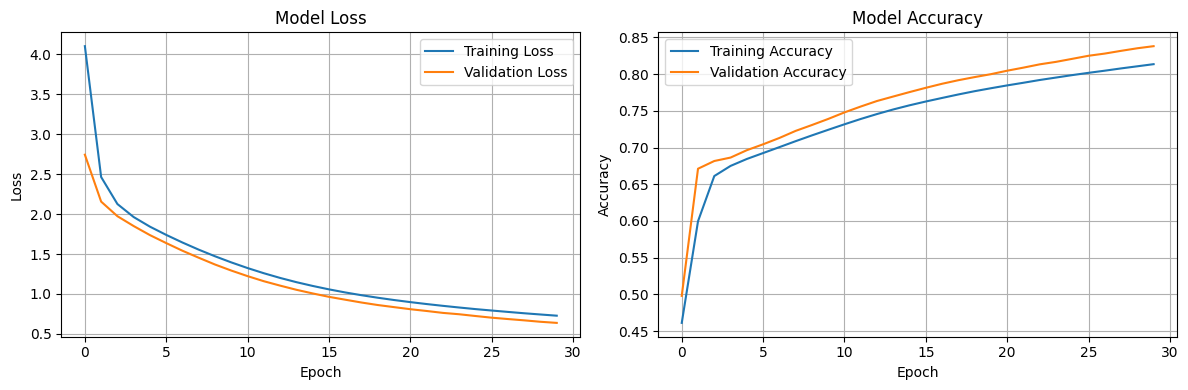


Model saved to: strudel_model.keras
Training plot saved to: training_history.png


In [ ]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

print(f"\nModel saved to: {config.MODEL_SAVE_PATH}")
print(f"Training plot saved to: training_history.png")

# Accuracy testing by masking random note in the test data

In [10]:
# full_load_and_eval.py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

# -------------------------
# PositionalEncoding layer
# -------------------------
@tf.keras.utils.register_keras_serializable()
class PositionalEncoding(layers.Layer):
    def __init__(self, seq_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_length = int(seq_length)
        self.d_model = int(d_model)
        self._pos_encoding = None

    def build(self, input_shape):
        # Build pos encoding with TF ops so dtype matches
        seq = tf.cast(tf.range(self.seq_length)[:, tf.newaxis], tf.float32)  # (seq_length,1)
        dims = tf.cast(tf.range(self.d_model)[tf.newaxis, :], tf.float32)    # (1,d_model)
        angle_rates = 1.0 / tf.pow(10000.0, (2.0 * (dims // 2)) / tf.cast(self.d_model, tf.float32))
        angle_rads = seq * angle_rates  # (seq_length, d_model)

        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])

        # Interleave sines and cosines into full matrix:
        # stack sines and cosines then reshape to (seq_length, d_model)
        # If d_model is odd, this still works because saved model likely used even d_model.
        stacked = tf.stack([sines, cosines], axis=-1)  # (seq_length, d_model/2, 2)
        # reshape carefully to (seq_length, d_model)
        angle_rads_full = tf.reshape(stacked, (self.seq_length, self.d_model))

        pos_encoding = angle_rads_full[tf.newaxis, ...]  # (1, seq_length, d_model)
        pos_encoding = tf.cast(pos_encoding, dtype=self.dtype)

        # store as a non-trainable weight so it's saved/loaded safely
        self._pos_encoding = self.add_weight(
            name="pos_encoding",
            shape=pos_encoding.shape,
            dtype=pos_encoding.dtype,
            initializer=tf.constant_initializer(pos_encoding.numpy()),
            trainable=False
        )
        super().build(input_shape)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self._pos_encoding[:, :seq_len, :]

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_length": self.seq_length, "d_model": self.d_model})
        return cfg

    @classmethod
    def from_config(cls, config):
        return cls(seq_length=config.pop("seq_length"), d_model=config.pop("d_model"), **config)


# -------------------------
# TransformerBlock layer
# -------------------------
@tf.keras.utils.register_keras_serializable()
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        """
        embed_dim: int, embedding dimension
        num_heads: int, attention heads
        ff_dim: int, hidden dim of feed-forward
        dropout_rate: float
        """
        super().__init__(**kwargs)
        self.embed_dim = int(embed_dim)
        self.num_heads = int(num_heads)
        self.ff_dim = int(ff_dim)
        self.dropout_rate = float(dropout_rate)

        # Layers (will be built lazily)
        self.att = layers.MultiHeadAttention(num_heads=self.num_heads, key_dim=self.embed_dim // self.num_heads)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential(
            [
                layers.Dense(self.ff_dim, activation="relu"),
                layers.Dense(self.embed_dim),
            ]
        )
        self.dropout1 = layers.Dropout(self.dropout_rate)
        self.dropout2 = layers.Dropout(self.dropout_rate)

    def call(self, inputs, training=False):
        # Multi-head self-attention
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(inputs + attn_output)

        # Feed-forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.norm2(out1 + ffn_output)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout_rate": self.dropout_rate
        })
        return cfg

    @classmethod
    def from_config(cls, config):
        return cls(embed_dim=config.pop("embed_dim"),
                   num_heads=config.pop("num_heads"),
                   ff_dim=config.pop("ff_dim"),
                   dropout_rate=config.pop("dropout_rate", 0.1),
                   **config)


# -------------------------
# Load model and evaluate masked predictions
# -------------------------
if __name__ == "__main__":
    MODEL_PATH = "transformer_model.keras"
    MASK_PROB = 0.15
    MASK_TOKEN = 0
    BATCH_SIZE = 32

    print("Loading model (custom_objects provided) ...")
    model = tf.keras.models.load_model(
        MODEL_PATH,
        custom_objects={
            "PositionalEncoding": PositionalEncoding,
            "TransformerBlock": TransformerBlock
        },
        compile=False  # avoid optimizer deserialization issues
    )
    print("Model loaded.")

    # infer shapes
    input_shape = model.input_shape  # (None, seq_len) or (None, seq_len, ?)
    output_shape = model.output_shape
    print("Model input shape:", input_shape)
    print("Model output shape:", output_shape)

    # -------------------------
    # NOTE: Replace following dummy-data with your real X_test/y_test arrays.
    # If you already have X_test and y_test loaded, remove this dummy block.
    # -------------------------
    if 'X_test' not in globals():
        # assume model expects integer token ids and model outputs vocab logits per position (batch, seq_len, vocab)
        seq_len = input_shape[1] if input_shape and len(input_shape) > 1 else 50
        # if output last dim exists, use it as vocab size, else set to 128
        vocab_size = output_shape[-1] if (output_shape and len(output_shape) >= 3) else 128
        num_samples = 200
        print("Creating dummy X_test/y_test (replace with your real data).")
        X_test = np.random.randint(1, vocab_size, size=(num_samples, seq_len))
        y_test = np.copy(X_test)

    # -------------------------
    # Masking
    # -------------------------
    X_masked = np.copy(X_test)
    mask_positions = np.random.rand(*X_masked.shape) < MASK_PROB
    X_masked[mask_positions] = MASK_TOKEN
    print("Total masked tokens:", np.sum(mask_positions))

    # -------------------------
    # Predict
    # -------------------------
    print("Predicting...")
    y_pred_probs = model.predict(X_masked, batch_size=BATCH_SIZE, verbose=1)

    # If model returns logits/probs per token (batch, seq_len, vocab)
    if y_pred_probs.ndim == 3:
        y_pred_int = np.argmax(y_pred_probs, axis=-1)
    elif y_pred_probs.ndim == 2 and X_masked.ndim == 2:
        # if model returns a class per position flattened, try to reshape
        raise ValueError("Model returned 2D outputs; expected (batch, seq_len, vocab). Check your model's final layer.")
    else:
        raise ValueError(f"Unexpected model output shape: {y_pred_probs.shape}")

    # -------------------------
    # Evaluate masked accuracy
    # -------------------------
    masked_true = y_test[mask_positions]
    masked_pred = y_pred_int[mask_positions]
    masked_accuracy = np.mean(masked_true == masked_pred) if masked_true.size > 0 else float("nan")
    print(f"Masked-note prediction accuracy: {masked_accuracy * 100:.2f}%")

    # Show a few examples
    indices = np.array(np.where(mask_positions)).T
    for idx in indices[:min(10, len(indices))]:
        i, j = int(idx[0]), int(idx[1])
        print(f"Seq {i}, Pos {j}: True={y_test[i, j]}, Pred={y_pred_int[i, j]}")


Loading model (custom_objects provided) ...


C:\Users\akshi\miniconda3\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
C:\Users\akshi\miniconda3\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
C:\Users\akshi\miniconda3\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_b

ValueError: A total of 25 objects could not be loaded. Example error message for object <PositionalEncoding name=positional_encoding_3, built=True>:

Layer 'positional_encoding_3' expected 1 variables, but received 0 variables during loading. Expected: ['pos_encoding']

List of objects that could not be loaded:
[<PositionalEncoding name=positional_encoding_3, built=True>, <EinsumDense name=key, built=True>, <EinsumDense name=attention_output, built=True>, <EinsumDense name=query, built=True>, <EinsumDense name=value, built=True>, <LayerNormalization name=layer_normalization_8, built=True>, <LayerNormalization name=layer_normalization_9, built=True>, <EinsumDense name=key, built=True>, <EinsumDense name=attention_output, built=True>, <EinsumDense name=query, built=True>, <EinsumDense name=value, built=True>, <LayerNormalization name=layer_normalization_10, built=True>, <LayerNormalization name=layer_normalization_11, built=True>, <EinsumDense name=key, built=True>, <EinsumDense name=att

# Generation

In [ ]:
# paths for model and vocabulary
MODEL_PATH = "transformer_model.keras"
DATA_DIR = "processed_data"

# load model with custom transformer objects
custom_objects = {"PositionalEncoding": PositionalEncoding, "TransformerBlock": TransformerBlock}
model = keras.models.load_model(MODEL_PATH, custom_objects=custom_objects)
print("Model loaded successfully!")

# load vocabulary
with open(f"{DATA_DIR}/vocabulary.json", "r") as f:
    vocabulary = json.load(f)

with open(f"{DATA_DIR}/reverse_vocab.json", "r") as f:
    reverse_vocab = {int(k): v for k, v in json.load(f).items()}

SEQUENCE_LENGTH = 50

# sample next token using temperature (higher temperature = more chaotic)
def sample_with_temperature(predictions, temperature=1.0):
    predictions = np.asarray(predictions).astype("float64")
    predictions = np.log(predictions + 1e-10) / temperature
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, predictions, 1)
    return np.argmax(probas)

# main generation loop
def generate_strudel_code(model, seed_text=None, max_tokens=200, temperature=1.0, num_lines=4):
    # start tokens if no seed
    if seed_text is None:
        generated_tokens = [vocabulary["<START>"], vocabulary["<CPM:120/4>"]]
    else:
        generated_tokens = [vocabulary.get(token, vocabulary["<PAD>"]) for token in seed_text.split()]
    
    for i in range(max_tokens):
        # pad if sequence too short
        if len(generated_tokens) < SEQUENCE_LENGTH:
            padded = [vocabulary["<PAD>"]] * (SEQUENCE_LENGTH - len(generated_tokens))
            input_seq = padded + generated_tokens
        else:
            input_seq = generated_tokens[-SEQUENCE_LENGTH:]
        
        input_seq = np.array([input_seq])
        predictions = model.predict(input_seq, verbose=0)
        next_token_probs = predictions[0, -1, :]
        next_token_idx = sample_with_temperature(next_token_probs, temperature)
        generated_tokens.append(next_token_idx)
        
        # stop after desired number of lines
        if reverse_vocab[next_token_idx] == "<SEP>":
            sep_count = sum(1 for t in generated_tokens if reverse_vocab[t] == "<SEP>")
            if sep_count >= num_lines:
                break
    
    generated_text_tokens = [reverse_vocab.get(idx, "<UNK>") for idx in generated_tokens]
    return format_as_strudel(generated_text_tokens)

# convert token list back to Strudel code
def format_as_strudel(tokens):
    output = []
    current_line = []
    cpm_value = "120/4"
    
    for token in tokens:
        if token.startswith("<CPM:"):
            cpm_value = token.replace("<CPM:", "").replace(">", "")
        elif token == "<START>":
            continue
        elif token == "<SEP>":
            if current_line:
                output.append(" ".join(current_line))
                current_line = []
            output.append(">`)")
            output.append("$: note(`<")
        elif token == "<END>":
            if current_line:
                output.append(" ".join(current_line))
                current_line = []
        elif token not in ["<PAD>", "<UNK>"]:
            current_line.append(token)
    
    if current_line:
        output.append(" ".join(current_line))
    
    code = f"setcpm({cpm_value})\n"
    code += "$: note(`<\n"
    code += "\n".join(output)
    if not output[-1].endswith(">`)"):
        code += "\n>`)"
    
    return code

# generate some Strudel pieces with different randomness levels
for temp in [1.5, 1.7, 1.9]:
    print(f"\n--- Temperature: {temp} ---")
    generated = generate_strudel_code(model, temperature=temp, max_tokens=150, num_lines=3)
    print(generated)
    print()



C:\Users\akshi\miniconda3\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
C:\Users\akshi\miniconda3\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
C:\Users\akshi\miniconda3\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_blo


Model loaded successfully!

--- Temperature: 1.5 ---
setcpm(120/4)
$: note(`<
[- - - - - - - b1] [- g#2 - g#2] [- c#1]
[- g2 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -] [c3,g3] [- b1 - b1]
>`)
$: note(`<
- - - -
f#3
>`)
$: note(`<
- [e4,g4] [e4,b4] [[b1,b3] [b1,b3] [d2,b3] b3]
- [f#3,a3] [f#4,a4,d5]
>`)
$: note(`<
>`)


--- Temperature: 1.7 ---
setcpm(120/4)
$: note(`<
[[d2,d3,a3,d4] - [a3,d4,f#4] - [d3,a3,d4,f#4] [d4,f#4] [d3,a3,d4] [g3,d4]] [e2 e2 - e2 e2 e2 - e2] [[c2,f#2,g#2,a#2,f#3] [c2,f#2,g#2] [d2,f#2,g#2,a#2,f#3] [c2,f#2,g#2] [c2,f#2,g#2,a#2,f#3] [c2,f#2,g#2] [d2,f#2,g#2,a#2,f#3] [c2,f#2,g#2]] [- g5 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -